# Reviewer 3 comment 1

Reviewer comment copy-pasted:
> The authors move away from understanding the "analytical range" of spectroscopic techniques, which leads to a distortion of the results of linear regression (Figure 3, Figure 4.). The authors combine the analytical range, which corresponds to linear regression with a high degree of correlation, and the area between the detection limit and the lower limit of the analytical range, which is inherently unsuitable for analytical interpretation. I think it is correct to compare the analytical range of the proposed technique with the linear domain of each dye. Of course, the analytical range of the proposed methodology will be broader (this is its advantage), but this is a normal situation when comparing.

Relevant sections from the paper:
- figure 3, 4

Tasks:
- seperate the MSE across the folds where concentrations in the analytical range (300+ au) and concentrations outside

In [1]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from whecho.whecho import whecho_simple

from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

c:\Users\craut\.virtualenvs\colorimetry_ML-6CtRR2jE\lib\site-packages\whecho\_utilities.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Step 1: added wv_456_645 -> 10-fold MSE: 23385.04
Step 2: added wv_429_273 -> 10-fold MSE: 9764.28
Step 3: added wv_490_682 -> 10-fold MSE: 7955.96
Step 4: added wv_631_853 -> 10-fold MSE: 8071.26
Step 5: added wv_425_679 -> 10-fold MSE: 3148.91
Step 6: added wv_631_058 -> 10-fold MSE: 2105.41
Step 7: added wv_408_722 -> 10-fold MSE: 2020.57
Step 8: added wv_482_359 -> 10-fold MSE: 407.76
Step 9: added wv_458_743 -> 10-fold MSE: 244.70
Step 10: added wv_541_638 -> 10-fold MSE: 30.37
Step 11: added wv_453_077 -> 10-fold MSE: 0.25
Step 12: added wv_627_077 -> 10-fold MSE: 5.73
Step 13: added wv_406_597 -> 10-fold MSE: 49.10
Step 14: added wv_629_068 -> 10-fold MSE: 97.23
Step 15: added wv_457_275 -> 10-fold MSE: 227.04
Step 16: added wv_633_046 -> 10-fold MSE: 288.59
Step 17: added wv_633_841 -> 10-fold MSE: 91.32
Step 18: added wv_410_846 -> 10-fold MSE: 86.57
Step 19: added wv_540_204 -> 10-fold MSE: 138.42
Step 20: added wv_412_968 -> 10-fold MSE: 254.48


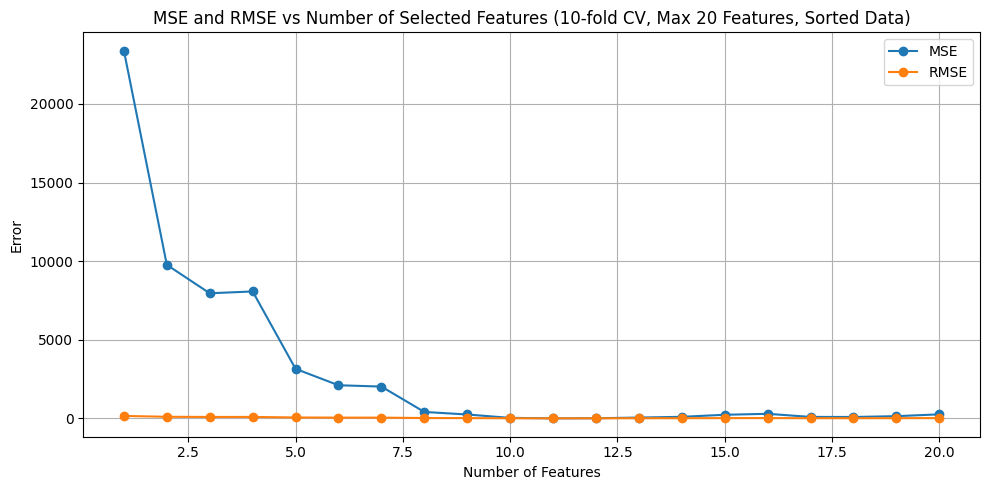

In [8]:
# === Load preprocessed sorted data ===
df = pd.read_csv("..\..\p11_new_paper_test\ML_colorimetric_data\ML colorimetric data\processed_sorted_transmission.csv", index_col=0)

# === Prepare X and y ===
X = df.copy()
y = X.index.values
X.reset_index(drop=True, inplace=True)

# === Optional: rename columns to valid variable names ===
X.columns = [f"wv_{str(c).replace('.', '_')}" for c in X.columns]

# === Define 10-fold CV MSE ===
def kfold_cv_mse(X_vals, y_vals, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_vals = []
    for train_idx, val_idx in kf.split(X_vals):
        X_train, X_val = X_vals[train_idx], X_vals[val_idx]
        y_train, y_val = y_vals[train_idx], y_vals[val_idx]
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_vals.append(mean_squared_error(y_val, y_pred))
    # make a dataframe to store the mse values for each fold
    mse_df = pd.DataFrame({"mse": mse_vals,"fold": range(1, n_splits + 1)})
    return np.mean(mse_vals), np.std(mse_vals) / np.sqrt(n_splits), mse_df

# === Greedy feature selection with a 20-feature cap ===
remaining = list(X.columns)
selected = []
data_list = []

best_mse = float("inf")
best_sem = None
max_features = 20  # Limit number of added features

all_data = []

for i in range(1, max_features + 1):
    best_mse_this_round = float("inf")
    best_candidate = None

    for candidate in remaining:
        test_features = selected + [candidate]
        mse, sem, mse_df = kfold_cv_mse(X[test_features].values, y, len(y)) # LOO
        mse_df["features"] = ", ".join(test_features)
        mse_df["n_feats"] = len(test_features)
        all_data.append(mse_df)
        if mse < best_mse_this_round:
            best_mse_this_round = mse
            best_sem = sem
            best_candidate = candidate

    if best_candidate is None:
        break

    selected.append(best_candidate)
    remaining.remove(best_candidate)
    best_mse = best_mse_this_round
    data_list.append({
        "n_feats": len(selected),
        "features": ", ".join(selected),
        "mse": best_mse,
        "rmse": np.sqrt(best_mse),
        "sem": best_sem
    })

    print(f"Step {len(selected)}: added {best_candidate} -> 10-fold MSE: {best_mse:.2f}")

# === Convert to DataFrame and Plot ===
results_df = pd.DataFrame(data_list)

plt.figure(figsize=(10, 5))
plt.plot(results_df["n_feats"], results_df["mse"], label="MSE", marker="o")
plt.plot(results_df["n_feats"], results_df["rmse"], label="RMSE", marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Error")
plt.title("MSE and RMSE vs Number of Selected Features (10-fold CV, Max 20 Features, Sorted Data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
all_data_df = pd.concat(all_data, ignore_index=True)
selected_features_df_subset = all_data_df[all_data_df.features.isin(results_df.features.tolist())].copy(deep=True)

# 1. Establish baselines per fold
fold_2_feat1_mse = {fold: mse for fold, n_feats, mse in zip(selected_features_df_subset.fold, selected_features_df_subset.n_feats, selected_features_df_subset.mse) if n_feats == 1}
selected_features_df_subset["1feat_baseline_mse"] = selected_features_df_subset.fold.map(fold_2_feat1_mse)

# 2. Calculate Log-Ratios at the fold level
# Log-improvement = ln(Baseline / Current)
selected_features_df_subset["log_mse_imp"] = np.log(selected_features_df_subset["1feat_baseline_mse"] / selected_features_df_subset["mse"])
# Note: RMSE improvement in log space is simply 0.5 * MSE log improvement
selected_features_df_subset["log_rmse_imp"] = 0.5 * selected_features_df_subset["log_mse_imp"]

# 3. Aggregate means and the SEM of the LOG values
summary_df = selected_features_df_subset.groupby("n_feats").agg(
    mean_mse=("mse", "mean"),
    se_mse=("mse", lambda x: np.std(x) / np.sqrt(len(x))),
    # Log-space stats for fold improvement
    mean_log_mse_imp=("log_mse_imp", "mean"),
    se_log_mse_imp=("log_mse_imp", lambda x: np.std(x) / np.sqrt(len(x))),
    mean_log_rmse_imp=("log_rmse_imp", "mean"),
    se_log_rmse_imp=("log_rmse_imp", lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

# 4. Transform back to original scale (Exponentiation)
# This gives the geometric mean of fold improvement, which is robust for ratios
summary_df["mean_mse_fold_improvement"] = np.exp(summary_df["mean_log_mse_imp"])
summary_df["mean_rmse_fold_improvement"] = np.exp(summary_df["mean_log_rmse_imp"])

# 5. Calculate Asymmetric Error Bars (95% CI)
z = 1.96

# MSE Fold Improvement Bounds
summary_df["mse_imp_low"] = np.exp(summary_df["mean_log_mse_imp"] - z * summary_df["se_log_mse_imp"])
summary_df["mse_imp_high"] = np.exp(summary_df["mean_log_mse_imp"] + z * summary_df["se_log_mse_imp"])

# RMSE Fold Improvement Bounds
summary_df["rmse_imp_low"] = np.exp(summary_df["mean_log_rmse_imp"] - z * summary_df["se_log_rmse_imp"])
summary_df["rmse_imp_high"] = np.exp(summary_df["mean_log_rmse_imp"] + z * summary_df["se_log_rmse_imp"])

# Standard RMSE for the RMSE-specific plot (Panel b/d)
summary_df["mean_rmse"] = np.sqrt(summary_df["mean_mse"])
# Delta method approximation for RMSE SEM
summary_df["se_rmse"] = summary_df["se_mse"] / (2 * summary_df["mean_rmse"])
summary_df

,n_feats,mean_mse,se_mse,mean_log_mse_imp,se_log_mse_imp,mean_log_rmse_imp,se_log_rmse_imp,mean_mse_fold_improvement,mean_rmse_fold_improvement,mse_imp_low,mse_imp_high,rmse_imp_low,rmse_imp_high,mean_rmse,se_rmse
0,1,23385.043137,5773.802098,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,152.921690,18.878297
1,2,9764.284635,3698.100336,2.129066,0.502862,1.064533,0.251431,8.407008,2.899484,3.137594,22.526109,1.771326,4.746168,98.814395,18.712356
2,3,7955.957849,2181.198862,1.242792,0.305609,0.621396,0.152805,3.465275,1.861525,1.903698,6.307792,1.379746,2.511532,89.196176,12.226975
3,4,8071.259094,2925.980992,1.704535,0.477504,0.852268,0.238752,5.498829,2.344958,2.156803,14.019413,1.468606,3.744251,89.840186,16.284366
4,5,3148.912789,747.678279,2.245606,0.666283,1.122803,0.333141,9.446140,3.073457,2.559194,34.866274,1.599748,5.904767,56.115174,6.661997
5,6,2105.406563,570.178846,2.078757,0.446648,1.039378,0.223324,7.994522,2.827459,3.331179,19.186114,1.825152,4.380196,45.884709,6.213168
6,7,2020.569719,501.749463,2.383635,0.583741,1.191818,0.291870,10.844252,3.293061,3.453897,34.047861,1.858466,5.835055,44.950748,5.581103
7,8,407.761888,105.426191,4.079271,0.615544,2.039635,0.307772,59.102346,7.687805,17.686555,197.499594,4.205539,14.053455,20.193115,2.610449
8,9,244.699927,60.530139,4.351882,0.560382,2.175941,0.280191,77.624416,8.810472,25.881605,232.812064,5.087397,15.258180,15.642887,1.934750
9,10,30.365594,9.854565,7.317080,0.708600,3.658540,0.354300,1505.800893,38.804650,375.487083,6038.653342,19.377489,77.708773,5.510499,0.894163


In [10]:
all_data_df

,mse,fold,features,n_feats
0,149922.219843,1,wv_400_216,1
1,29984.111087,2,wv_400_216,1
2,474526.081090,3,wv_400_216,1
3,2066.560780,4,wv_400_216,1
4,59653.647950,5,wv_400_216,1
...,...,...,...,...
86965,5502.897130,9,"wv_456_645, wv_429_273, wv_490_682, wv_631_853...",20
86966,421.101911,10,"wv_456_645, wv_429_273, wv_490_682, wv_631_853...",20
86967,0.974381,11,"wv_456_645, wv_429_273, wv_490_682, wv_631_853...",20
86968,1921.892288,12,"wv_456_645, wv_429_273, wv_490_682, wv_631_853...",20


In [34]:
fold_i = 0
n_splits = len(y)
X_vals = X.values
y_vals = y
fold_i_in_analrange = set()
fold_i_in_analrange2 = set()
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_vals):
    X_train, X_val = X_vals[train_idx], X_vals[val_idx]
    y_train, y_val = y_vals[train_idx], y_vals[val_idx]
    print(f"Fold {fold_i}: Validation Y-vals: {y_val}")
    if y_val[0] >= 300:
        fold_i_in_analrange.add(fold_i)
    if y_val[0] <= 200:
        fold_i_in_analrange2.add(fold_i)
    fold_i += 1
    

Fold 0: Validation Y-vals: [900.]
Fold 1: Validation Y-vals: [700.]
Fold 2: Validation Y-vals: [20.]
Fold 3: Validation Y-vals: [600.]
Fold 4: Validation Y-vals: [300.]
Fold 5: Validation Y-vals: [50.]
Fold 6: Validation Y-vals: [40.]
Fold 7: Validation Y-vals: [1000.]
Fold 8: Validation Y-vals: [200.]
Fold 9: Validation Y-vals: [500.]
Fold 10: Validation Y-vals: [800.]
Fold 11: Validation Y-vals: [100.]
Fold 12: Validation Y-vals: [400.]


In [37]:
# calculate the summary table using only the folds that are in the analysis range (i.e. where the validation samples have y >= 300)
summary_df_analrange = selected_features_df_subset[selected_features_df_subset.fold.isin(fold_i_in_analrange)].groupby("n_feats").agg(
    mean_mse=("mse", "mean"),
    std_mse=("mse", "std")
).reset_index()
tmp1 = summary_df_analrange[["n_feats", "mean_mse"]].merge(summary_df[["n_feats", "mean_mse"]], on="n_feats", suffixes=("_analrange", "_full"))
summary_df_analrange2 = selected_features_df_subset[selected_features_df_subset.fold.isin(fold_i_in_analrange2)].groupby("n_feats").agg(
    mean_mse=("mse", "mean"),
    std_mse=("mse", "std")
).reset_index()
tmp2 = summary_df_analrange2[["n_feats", "mean_mse"]].merge(summary_df[["n_feats", "mean_mse"]], on="n_feats", suffixes=("_analrange2", "_full"))
tmp1.merge(tmp2, on=["n_feats","mean_mse_full"]).merge(summary_df, on="n_feats")[["mean_mse_analrange2"]]

,mean_mse_analrange2
0,16690.810376
1,13150.804411
2,9408.725410
3,10920.511228
4,2325.366487
5,2955.355524
6,2714.594606
7,259.735256
8,264.468983
9,23.932455


In [28]:
# load the trans vs conc data
d1 = pd.read_csv("../..\\p11_new_paper_test\\ML_colorimetric_data\\ML colorimetric data\\transmission_vs_concentration_columns.csv")
d2 = pd.read_csv("../..\\p11_new_paper_test\\ML_colorimetric_data\\ML colorimetric data\\trans_vs_conc_best_and_worst.csv")
d12 = d1.merge(d2, on="Concentration (ppm)")
d12

,Concentration (ppm),400.2 nm,425.0 nm,449.7 nm,474.9 nm,499.8 nm,525.2 nm,549.8 nm,574.8 nm,599.9 nm,625.1 nm,639.8 nm,Transmission at 457.275 nm,Transmission at 609.900 nm
0,20.0,343.126814,1778.833786,6172.506409,12682.921579,24445.452436,29113.155267,25673.761143,11602.026466,3230.587704,174.511851,311.199485,7489.023125,1424.191036
1,40.0,153.666658,1115.353135,5544.138581,11487.980172,21259.287584,22901.286684,14648.071033,2894.744725,84.370968,-3.844253,129.681640,6827.546045,-66.341094
2,50.0,64.403555,732.799247,4856.234163,10317.209290,18959.818401,18889.549488,10515.622453,1445.084022,-90.843901,-30.488492,48.623280,5997.788685,-124.547437
3,100.0,-34.014747,345.492357,4020.752840,8440.630809,13950.494757,11698.755238,3875.950110,63.764025,-176.277171,-74.772775,-32.516382,5203.485759,-156.247686
4,200.0,-84.900210,-15.177507,3216.890888,7743.017204,11554.847539,5841.216780,524.969302,-104.707138,-175.268739,-58.326104,-84.825270,4409.471844,-162.827089
5,300.0,-79.724296,-39.735175,2232.464662,6006.809985,7868.774985,2993.854592,23.207768,-147.069156,-189.628558,-84.713852,-88.117517,3422.414817,-158.880748
6,400.0,-110.747403,-75.124850,2081.541354,5953.707869,6249.898672,1258.144659,-130.687526,-168.251718,-184.204920,-111.198171,-109.250451,3442.314926,-166.378373
7,500.0,-87.490288,-32.794789,1882.989342,5428.394269,6106.440468,1512.595304,-50.815330,-164.195230,-205.253865,-118.776814,-85.371339,3233.088562,-183.495964
8,600.0,-101.500719,-64.106625,1593.332837,4825.922839,4986.226024,914.644845,-116.429653,-151.253464,-203.968723,-108.455385,-101.120932,2925.653585,-180.128919
9,700.0,-92.271144,-37.792970,1378.423657,4179.984390,3652.448340,462.065808,-101.998289,-173.371498,-209.914958,-139.174775,-94.942242,2514.001261,-194.155610


In [33]:
# for each of the columns that are not "Concentration (ppm)", perform a linear regression to predict the concentration from the transmission values, and report the R^2 value for each column
def get_rmse_and_r2_for_column(col, conc_subset=None):
    if conc_subset is not None:
        subset_df = d12[d12["Concentration (ppm)"].isin(conc_subset)]
    else:
        subset_df = d12
    X_col = subset_df[[col]].values
    y_col = subset_df["Concentration (ppm)"].values
    model = LinearRegression().fit(X_col, y_col)
    r2 = model.score(X_col, y_col)
    rmse = np.sqrt(mean_squared_error(y_col, model.predict(X_col)))
    return rmse, r2

r2_table_data = []
for col in d12.columns:
    if col != "Concentration (ppm)":
        rmse_full, r2_full = get_rmse_and_r2_for_column(col)
        rmse_subset, r2_subset = get_rmse_and_r2_for_column(col, conc_subset=d12[d12["Concentration (ppm)"] >= 300]["Concentration (ppm)"].unique())
        wavelength_int = int(round(float(str(col).replace(" nm", "").replace("Transmission at ",""))))
        rmse_subset2, r2_subset2 = get_rmse_and_r2_for_column(col, conc_subset=d12[d12["Concentration (ppm)"] <= 200]["Concentration (ppm)"].unique())
        r2_table_data.append({
            "wavelength": wavelength_int,
            "rsme (all concentrations)": rmse_full,
            "rsme (au >= 300)": rmse_subset,
            "rsme (au <= 200)": rmse_subset2,
            "r2 (all concentrations)": r2_full,
            "r2 (au >= 300)": r2_subset,
            "r2 (au <= 200)": r2_subset2
        })
r2_fully = pd.DataFrame(r2_table_data)
r2_fully

,wavelength,rsme (all concentrations),rsme (au >= 300),rsme (au <= 200),r2 (all concentrations),r2 (au >= 300),r2 (au <= 200)
0,400,247.206260,198.618406,36.445927,0.445829,0.248585,0.681919
1,425,238.016482,159.532607,31.065955,0.486265,0.515226,0.768895
2,450,134.459594,56.114779,22.524199,0.836051,0.940022,0.878511
3,475,129.688422,76.518503,28.614153,0.847480,0.888475,0.803934
4,500,143.827888,51.243334,25.335612,0.812409,0.949983,0.846290
5,525,198.720222,93.443600,23.093852,0.641896,0.833682,0.872288
6,550,249.179838,137.517308,34.466658,0.436945,0.639790,0.715529
7,575,288.581737,223.295774,49.682721,0.244799,0.050267,0.408915
8,600,304.102641,228.653183,55.098395,0.161380,0.004147,0.273028
9,625,252.507990,220.290565,50.863853,0.421804,0.075658,0.380476


In [27]:
d2

,Concentration (ppm),Transmission at 457.275 nm,Transmission at 609.900 nm
0,20.0,7489.023125,1424.191036
1,40.0,6827.546045,-66.341094
2,50.0,5997.788685,-124.547437
3,100.0,5203.485759,-156.247686
4,200.0,4409.471844,-162.827089
5,300.0,3422.414817,-158.880748
6,400.0,3442.314926,-166.378373
7,500.0,3233.088562,-183.495964
8,600.0,2925.653585,-180.128919
9,700.0,2514.001261,-194.155610
